In [2]:
import sys
sys.path.append("../src")

In [3]:
from data_loader import load_data

df = load_data("../data/raw/complaints.csv")

print(df.shape)
df.head()

c:\Users\habtamu.amsalu\Downloads\rag-complaint-chatbot-\notebooks\../src\data_loader.py:4: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


(9609797, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

from eda import (plot_product_distribution,
                 narrative_length_analysis,
                 narrative_presence_analysis)


from preprocessing import (filter_by_groups,remove_empty_narratives,clean_text)

c:\Users\habtamu.amsalu\Downloads\rag-complaint-chatbot-\notebooks\../src\eda.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


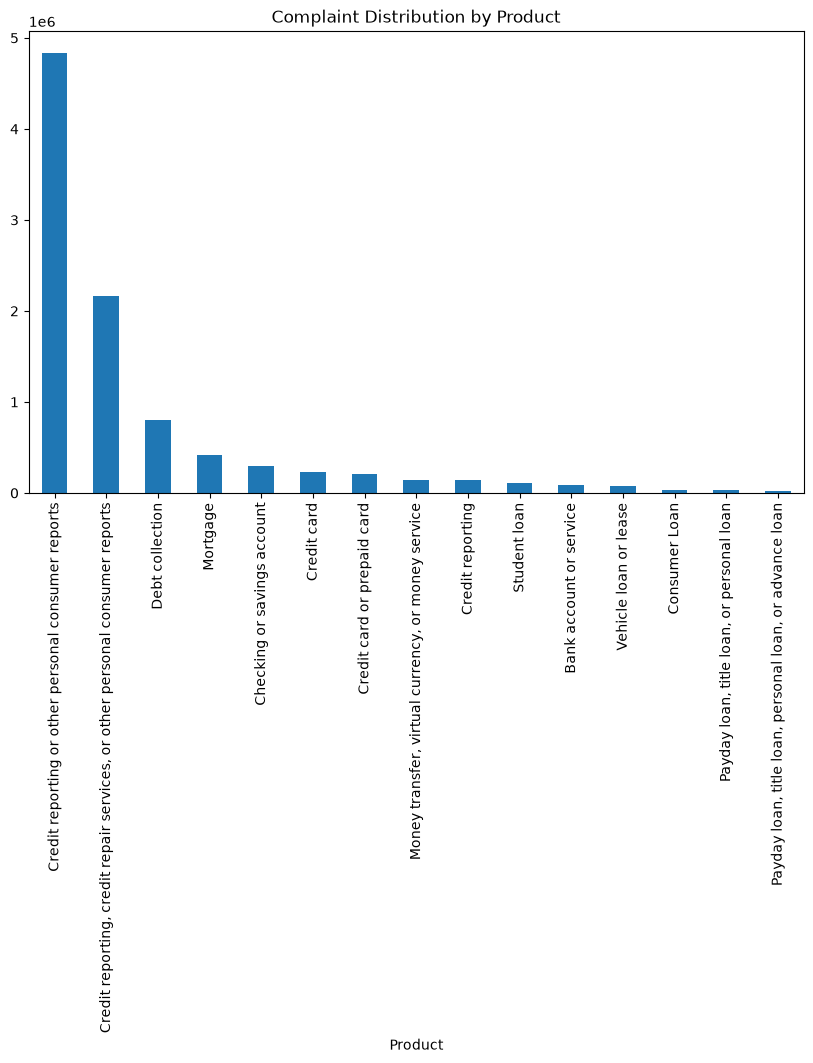

In [4]:
plot_product_distribution(df)

In [5]:
from eda import plot_product_distribution

print(plot_product_distribution.__module__)

eda


In [6]:
import eda
print(eda.__file__)

c:\Users\habtamu.amsalu\Downloads\rag-complaint-chatbot-\notebooks\../src\eda.py


In [7]:
import inspect
import eda

print(eda.__file__)
print(inspect.getsource(eda.plot_product_distribution))

c:\Users\habtamu.amsalu\Downloads\rag-complaint-chatbot-\notebooks\../src\eda.py
def plot_product_distribution(df):

    product_counts = (
        df["Product"]
        .value_counts()
        .head(15)
    )

    product_counts.plot(
        kind="bar",
        figsize=(10,6)
    )

    plt.title("Complaint Distribution by Product")
    plt.tight_layout()
    plt.show()



In [8]:
print(df.columns)

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='str')


In [9]:
import eda

print(dir(eda))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '__warningregistry__', 'narrative_length_analysis', 'narrative_presence_analysis', 'plot_product_distribution', 'plt']


In [10]:
df = narrative_length_analysis(df)

count    9.609797e+06
mean     5.446667e+01
std      1.497672e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      5.000000e+01
max      6.469000e+03
Name: word_count, dtype: float64


In [11]:
narrative_presence_analysis(df)

With Narrative: 2980756
Without Narrative: 6629041


In [12]:
credit_card_products = [
    "Credit card",
    "Credit card or prepaid card"
]
personal_loan_products = [
    "Payday loan, title loan, personal loan, or advance loan",
    "Payday loan, title loan, or personal loan",
    "Consumer Loan"
]
savings_products = [
    "Checking or savings account",
    "Bank account or service"
]
money_transfer_products = [
    "Money transfer, virtual currency, or money service",
    "Money transfers"
]

In [13]:
target_products = [
    "credit_card_products",
    "personal_loan_products",
    "savings_products",
    "money_transfer_products"
]

In [42]:
product_mapping = {
    "Credit Card": [
        "Credit card",
        "Credit card or prepaid card"
    ],
    "Personal Loan": [
        "Payday loan, title loan, personal loan, or advance loan",
        "Payday loan, title loan, or personal loan",
        "Consumer Loan"
    ],
    "Savings Account": [
        "Checking or savings account",
        "Bank account or service"
    ],
    "Money Transfer": [
        "Money transfer, virtual currency, or money service",
        "Money transfers"
    ]
}

In [43]:
from preprocessing import filter_products
filtered_df = filter_products(df, target_products)

lookup = {item: category for category, items in product_mapping.items() for item in items}

# Map the "Product" column to the new category
filtered_df['Category'] = filtered_df['Product'].map(lookup)

# Now check the counts
print(filtered_df['Category'].value_counts())

Series([], Name: count, dtype: int64)


In [37]:
import pandas as pd
mapping_df = pd.DataFrame({
    "Original_Product": df["Product"].unique()
})

mapping_df

,Original_Product
0,Credit reporting or other personal consumer re...
1,Debt collection
2,Credit card
3,Checking or savings account
4,"Money transfer, virtual currency, or money ser..."
5,Vehicle loan or lease
6,Debt or credit management
7,Mortgage
8,"Payday loan, title loan, personal loan, or adv..."
9,Prepaid card


In [5]:

target_products = [
    "credit_card",
    "personal_loan",
    "savings_products",
    "money_transfer"
]

filtered_df = filter_by_groups(df, target_products)

In [11]:
from preprocessing import product_map
for group in target_products:
    products = product_map[group]
    count = df[df["Product"].isin(products)].shape[0]
    print(group, count)

credit_card 433055
personal_loan 78729
savings_products 377383
money_transfer 150420


In [30]:

filtered_df["Product"] = (
    filtered_df["Product"]
    .map(product_mapping)
)

In [33]:
print(filtered_df["Product"].value_counts())

Series([], Name: count, dtype: int64)


In [12]:
filtered_df = remove_empty_narratives(filtered_df)

In [13]:
from preprocessing import clean_text

filtered_df["cleaned_narrative"] = (
    filtered_df["Consumer complaint narrative"]
    .apply(clean_text)
)

In [14]:

# Assuming 'df' with 'word_count' is available from previous steps
# If not, re-run narrative_length_analysis(df) earlier.

plt.figure(figsize=(12, 6))
sns.histplot(df['word_count'][df['word_count'] > 0], bins=50, kde=True)
plt.title('Distribution of Consumer Narrative Lengths (Word Count)')
plt.xlabel('Word Count')
plt.ylabel('Number of Complaints')
plt.xlim(0, 500) # Limit x-axis for better visualization of common lengths
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x=df['word_count'])
plt.title('Box Plot of Consumer Narrative Lengths (Word Count)')
plt.xlabel('Word Count')
plt.xscale('log') # Use log scale for better visualization of outliers
plt.show()

KeyError: 'word_count'

<Figure size 1200x600 with 0 Axes>

In [15]:
print("===== BEFORE CLEANING =====")

df[['Consumer complaint narrative']].head()

===== BEFORE CLEANING =====


,Consumer complaint narrative
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


In [16]:
filtered_df["cleaned_narrative"] = (
    filtered_df["Consumer complaint narrative"]
    .apply(clean_text)
)

In [17]:
print("===== AFTER CLEANING =====")

filtered_df[['cleaned_narrative']].head()

===== AFTER CLEANING =====


,cleaned_narrative
12237,a card was opened under my name by a fraudster...
12532,i made the mistake of using my wellsfargo debi...
13280,i have a secured credit card with citibank whi...
13506,i have a citi rewards cards the credit balance...
13955,the following charges on my citi credit card a...


In [18]:
comparison = filtered_df[
    ['Consumer complaint narrative']
].copy()

comparison['cleaned_narrative'] = (
    filtered_df['Consumer complaint narrative']
    .apply(clean_text)
)

comparison.head()

,Consumer complaint narrative,cleaned_narrative
12237,A XXXX XXXX card was opened under my name by a...,a card was opened under my name by a fraudster...
12532,I made the mistake of using my wellsfargo debi...,i made the mistake of using my wellsfargo debi...
13280,"Dear CFPB, I have a secured credit card with c...",i have a secured credit card with citibank whi...
13506,I have a Citi rewards cards. The credit balanc...,i have a citi rewards cards the credit balance...
13955,b'I am writing to dispute the following charge...,the following charges on my citi credit card a...


In [20]:
filtered_df.to_csv(
    "../data/filtered_complaints.csv",
    index=False
)

print("Saved successfully")

Saved successfully


In [21]:

df = load_data("../data/filtered_complaints.csv")

print(df.shape)
df.head()

(478818, 19)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,cleaned_narrative
0,2025-06-13,Credit card,Store credit card,Getting a credit card,Card opened without my consent or knowledge,A XXXX XXXX card was opened under my name by a...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78230,Servicemember,Consent provided,Web,2025-06-13,Closed with non-monetary relief,Yes,NaN,14069121,a card was opened under my name by a fraudster...
1,2025-06-13,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,I made the mistake of using my wellsfargo debi...,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,ID,83815,NaN,Consent provided,Web,2025-06-13,Closed with explanation,Yes,NaN,14061897,i made the mistake of using my wellsfargo debi...
2,2025-06-12,Credit card,General-purpose credit card or charge card,"Other features, terms, or problems",Other problem,"Dear CFPB, I have a secured credit card with c...",Company has responded to the consumer and the ...,"CITIBANK, N.A.",NY,11220,NaN,Consent provided,Web,2025-06-13,Closed with monetary relief,Yes,NaN,14047085,i have a secured credit card with citibank whi...
3,2025-06-12,Credit card,General-purpose credit card or charge card,Incorrect information on your report,Account information incorrect,I have a Citi rewards cards. The credit balanc...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",IL,60067,NaN,Consent provided,Web,2025-06-12,Closed with explanation,Yes,NaN,14040217,i have a citi rewards cards the credit balance...
4,2025-06-09,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,b'I am writing to dispute the following charge...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78413,Older American,Consent provided,Web,2025-06-09,Closed with monetary relief,Yes,NaN,13968411,the following charges on my citi credit card a...


In [ ]:
print(df["Product"].value_counts())